In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

# Importing config.py file
import config as cf
from utils import *

# Importing python packages
import os
import math
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Checking for GPU instance
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Intilizaing the accuracy value as zero
best_acc = 0

In [5]:
print('\n[Phase 1] : Data Preparation')

# Dataset
dataset = 'cifar100'

# Preparing the dataset
transform_train = transforms.Compose([
    transforms.RandomCrop(32),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(cf.mean[dataset], cf.std[dataset]),
]) # mean and std transformation

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cf.mean[dataset], cf.std[dataset]),
])


[Phase 1] : Data Preparation


In [6]:
# Number of classes in the dataset
num_classes = 100

In [8]:
# Downloading the dataset
trainset = torchvision.datasets.CIFAR100(root='../../datasets/cifar100', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR100(root='../../datasets/cifar100', train=False, download=False, transform=transform_test)

# Loading the dataset
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=8)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=8)

100%|██████████| 169M/169M [00:31<00:00, 5.44MB/s] 


In [10]:
class LeNet(nn.Module):
    def __init__(self, num_classes, init_mode='xavier'):  # Supports 'zero', 'normal', 'xavier', 'he' initializations
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1   = nn.Linear(16*5*5, 120)
        self.fc2   = nn.Linear(120, 84)
        self.fc3   = nn.Linear(84, num_classes)

        if init_mode == 'zero':
            for m in self.modules():
                if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                    m.weight.data.zero_()   # Fill tensor elements with zeros
                    if m.bias is not None:
                        m.bias.data.zero_()

        if init_mode == 'normal':
            for m in self.modules():
                if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
                    m.weight.data.normal_()   # Fill tensor elements with random numbers from normal distribution
                    if m.bias is not None:
                        m.bias.data.normal_()

        if init_mode == 'xavier':
            for m in self.modules():
                if isinstance(m, nn.Conv2d):
                    fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                    fan_in = m.kernel_size[0] * m.kernel_size[1] * m.in_channels
                    n = fan_in + fan_out
                    m.weight.data.normal_(0, math.sqrt(2. / n))
                    if m.bias is not None:
                        m.bias.data.normal_(0, math.sqrt(2. / n))
                if isinstance(m, nn.Linear):
                    size = m.weight.size()
                    fan_out = size[0] # Number of rows
                    fan_in = size[1] # Number of columns
                    variance = math.sqrt(2.0/(fan_in+fan_out))
                    m.weight.data.normal_(0.0, variance)
                    if m.bias is not None:
                        m.bias.data.normal_(0, variance)

        if init_mode == 'he':
            for m in self.modules():
                if isinstance(m, nn.Conv2d):
                    n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
                    m.weight.data.normal_(0, math.sqrt(2. / n))
                    if m.bias is not None:
                        m.bias.data.normal_(0, math.sqrt(2. / n))
                if isinstance(m, nn.Linear):
                    size = m.weight.size()
                    fan_out = size[0] # Number of rows
                    fan_in = size[1] # Number of columns
                    variance = math.sqrt(2.0/(fan_in))
                    m.weight.data.normal_(0.0, variance)
                    if m.bias is not None:
                        m.bias.data.normal_(0, variance)


    # Forward Pass
    def forward(self, x):
        out = F.relu(self.conv1(x))
        out = F.max_pool2d(out, 2)
        out = F.relu(self.conv2(out))
        out = F.max_pool2d(out, 2)
        out = out.view(out.size(0), -1)
        out = F.relu(self.fc1(out))
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return(out)

In [11]:
# Calling the model with Xavier
net = LeNet(num_classes, init_mode='xavier')  # You rerun this entire experiment alternate values to 'xavier' (check ungraded exercise below)
# Checking for GPU instance
net = net.to(device)

In [12]:
# Intiliazing the loss
criterion = nn.CrossEntropyLoss()

In [13]:
def train(epoch):
    print('\nEpoch: %d' % epoch)

    net.train()

    train_loss = 0
    correct = 0
    total = 0

    # Looping over train data
    for batch_idx, (inputs, targets) in enumerate(trainloader):

        # Converting inputs and targets into pytorch variables
        inputs, targets = inputs.to(device), targets.to(device)

        # Set the parameters of gradients to zero
        optimizer.zero_grad()

        # Forward Pass
        outputs = net(inputs)

        # Storing the outputs size
        size_ = outputs.size()

        # Reducing the dimenssion
        outputs_ = outputs.view(size_[0], num_classes)

        # Calculating the loss
        loss = criterion(outputs_, targets)

        # Backward Pass
        loss.backward()

        # Update the weights
        optimizer.step()

        # Calculating the train loss
        train_loss += loss.item()

        # Predicting the values
        _, predicted = torch.max(outputs_.data, 1)

        # Storing the targets size
        total += targets.size(0)

        # Calculating the corrected values
        correct += predicted.eq(targets.data).cpu().sum().item()

        # Printing the data
        if batch_idx % 30 == 0 or batch_idx == len(trainloader)-1:
            # Printing the progress bar
            progress_bar(batch_idx, len(trainloader), 'Loss: %.3f | Acc: %.3f%% (%d/%d)'
                         % (train_loss/(batch_idx+1), 100.*correct/total, correct, total))

    # Storing number of epoch, loss and accuracy in a file
    train_loss_file.write('%d %.3f %.3f\n' %(epoch, train_loss/len(trainloader), 100.*correct/total))

In [14]:
def test(epoch):
    global best_acc
    net.eval()

    test_loss = 0
    correct = 0
    total = 0

    # Looping over the test data
    for batch_idx, (inputs, targets) in enumerate(testloader):

        # Coverting inputs and targets intp pytorch variables
        inputs, targets = inputs.to(device), targets.to(device)

        # Forward pass
        outputs = net(inputs)

        # Storing the size of outputs
        size_ = outputs.size()

        # Reducing the dimenssion
        outputs_ = outputs.view(size_[0], num_classes)

        # Calculating the loss
        loss = criterion(outputs_, targets)

        # Calculating the test loss
        test_loss += loss.item()

        # Predicted values
        _, predicted = torch.max(outputs_.data, 1)

        # Storing the size of targets
        total += targets.size(0)

        # Calculating the correct values
        correct += predicted.eq(targets.data).cpu().sum().item()

        # Printing the data
        if batch_idx%30 == 0 or batch_idx == len(testloader)-1:
            # printing the progress bar
            progress_bar(batch_idx, len(testloader), 'Loss: %.3f | Acc: %.3f%% (%d/%d)'
                         % (test_loss/(batch_idx+1), 100.*correct/total, correct, total))
    # Printing the validation loss
    print('val_loss: ',  test_loss/len(testloader), 'accuracy: ', 100.0*correct/total)
    # Storing number of epoch,loss and acuracy in a file
    val_loss_file.write('%d %.3f %.3f\n' %(epoch,  test_loss/len(testloader), 100.*correct/total))

    # Save checkpoint.
    acc = 100.*correct/total

    # Checking for best accuracy
    if acc > best_acc:
        print('Saving..')
        state = {
            'net': net,
            'acc': acc,
            'epoch': epoch,
        }
        # Checking for the directory
        if not os.path.isdir('../checkpoint'):
            # Creating the directory
            os.mkdir('../checkpoint')
        # Saving the data
        torch.save(state, '../checkpoint_ckpt.t7')
        # Storing the accuracy value
        best_acc = acc

In [15]:
experiment = 'no_momentum'
# Creating files in write mode
train_loss_file = open(experiment+"train_loss.txt", "w")
val_loss_file = open(experiment+"val_loss.txt", "w")

In [16]:
# Optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0)

# Training and Testing the model for 30 epochs
for epoch in range(0, 30):
    # Training the model
    train(epoch)
    # Testing the model
    test(epoch)
# Closing the values
train_loss_file.close()
val_loss_file.close()


Epoch: 0
 [==================================>] | Loss: 4.608 | Acc: 1.056% (528/50000)  391/391 
 [==================================>] | Loss: 4.593 | Acc: 1.840% (184/10000)  100/100 
val_loss:  4.592656040191651 accuracy:  1.84
Saving..

Epoch: 1
 [==================================>] | Loss: 4.572 | Acc: 2.018% (1009/50000) 391/391 
 [==================================>] | Loss: 4.542 | Acc: 2.470% (247/10000)  100/100 
val_loss:  4.541808371543884 accuracy:  2.47
Saving..

Epoch: 2
 [==================================>] | Loss: 4.468 | Acc: 3.258% (1629/50000) 391/391 
 [==================================>] | Loss: 4.378 | Acc: 4.070% (407/10000)  100/100 
val_loss:  4.377796010971069 accuracy:  4.07
Saving..

Epoch: 3
 [==================================>] | Loss: 4.248 | Acc: 5.720% (2860/50000) 391/391 
 [==================================>] | Loss: 4.168 | Acc: 6.370% (637/10000)  100/100 
val_loss:  4.167668764591217 accuracy:  6.37
Saving..

Epoch: 4
 [====================

30 30


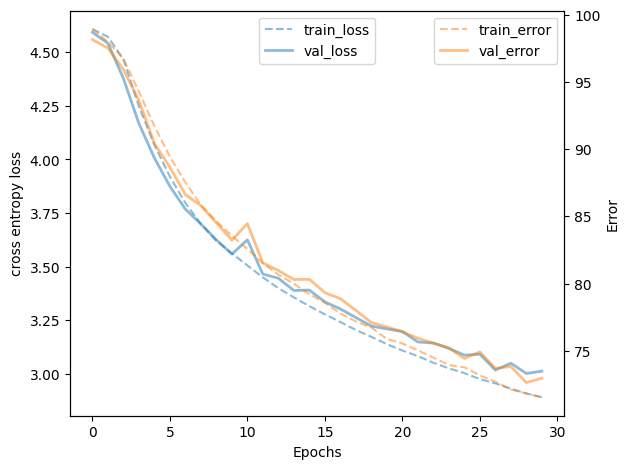

In [17]:
training_curves(experiment)

In [18]:
# Calling the model
net = LeNet(num_classes, init_mode='xavier')
# Checking for GPU instance
net = net.to(device)

In [19]:
experiment = 'with_momentum'
# Cretaing files in write mode
train_loss_file = open(experiment+"train_loss.txt", "w")
val_loss_file = open(experiment+"val_loss.txt", "w")

In [20]:
# Optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

# Training and Testing the model for 10 epochs
for epoch in range(0, 10):
    # Training the model
    train(epoch)
    # Testing the model
    test(epoch)

# Closing the files
train_loss_file.close()
val_loss_file.close()


Epoch: 0
 [==================================>] | Loss: 4.265 | Acc: 5.604% (2802/50000) 391/391 
 [==================================>] | Loss: 3.898 | Acc: 10.830% (1083/10000 100/100 ====================>.............] | Loss: 3.895 | Acc: 10.656% (650/6100)  61/100 ===============================>...] | Loss: 3.896 | Acc: 10.868% (989/9100)  91/100 
val_loss:  3.8975598573684693 accuracy:  10.83

Epoch: 1
 [==================================>] | Loss: 3.708 | Acc: 13.638% (6819/50000 391/391 
 [==================================>] | Loss: 3.528 | Acc: 16.960% (1696/10000 100/100 
val_loss:  3.5282345843315124 accuracy:  16.96

Epoch: 2
 [==================================>] | Loss: 3.428 | Acc: 18.308% (9154/50000 391/391 
 [==================================>] | Loss: 3.370 | Acc: 19.160% (1916/10000 100/100 
val_loss:  3.3698601770401 accuracy:  19.16

Epoch: 3
 [==================================>] | Loss: 3.269 | Acc: 21.138% (10569/50000 391/391 
 [===========================

In [ ]:
training_curves(experiment)